In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mne.filter import filter_data

### COnfig

In [16]:
CHANNEL_NAMES = [
    "FP1",
    "F3",
    "F7",
    "C3",
    "T3",
    "P3",
    "T5",
    "O1",
    "FP2",
    "F4",
    "F8",
    "C4",
    "T4",
    "P4",
    "T6",
    "O2"
]

#### Load data

In [7]:
# Loading EEG
df_eeg = pd.read_csv("../data/subjectV/V_eeg_20260617_150226.csv")
timestamps = df_eeg.lsl_timestamp.values
EEG = df_eeg.iloc[:, 1:-1].values
button = df_eeg.iloc[:, -1].values.astype(bool)

N_CHANNELS = EEG.shape[1]
FS = 250. # Sampling frequency

## Go/No-Go Task (`scripts/gng_task.py`)

PyGame + LSL experiment for motor intention data collection.

**Run:**
```bash
python scripts/gng_task.py --out-dir data/gng --prefix S01
```

Outputs two CSVs per session: `<prefix>_markers_<datetime>.csv` and `<prefix>_eeg_<datetime>.csv`.

### LSL Marker Codes

| Code | Label | Meaning |
|------|-------|---------|
| 5 | `S1_warning` | S1 warning cue onset |
| 10 | `go_onset` | Go stimulus (S2) onset |
| 20 | `nogo_onset` | No-Go stimulus (S2) onset |
| 30 | `button_press` | Button press detected |
| 11 | `hit` | Go + pressed in time |
| 12 | `miss` | Go + no press |
| 21 | `correct_rejection` | No-Go + no press |
| 22 | `false_alarm` | No-Go + pressed |
| 99 | `end` | Experiment end |


In [8]:
# Loading markers
df_markers = pd.read_csv("../data/subjectV/V_markers_20260617_150226.csv")

### Preprocess EEG

In [9]:
EEG = filter_data(EEG.T[None], 250, .5, 28., verbose=False).squeeze()

### Check evoked potentials

In [24]:
WINDOW = 1.5
N_SAMPLES = int(WINDOW * FS) + 1  # fixed epoch length
T_ARRAY = np.arange(0, WINDOW + 1 / FS, 1 / FS)

In [25]:
go_onsets = df_markers.loc[df_markers.marker_code == 10].lsl_timestamp.values

GO_ERP = []

for onset in go_onsets:
    idx_start = np.searchsorted(timestamps, onset)
    GO_ERP.append(EEG[:, idx_start : idx_start + N_SAMPLES])

GO_ERP = np.stack(GO_ERP)


In [26]:
nogo_onsets = df_markers.loc[df_markers.marker_code == 20].lsl_timestamp.values

NOGO_ERP = []

for onset in nogo_onsets:
    idx_start = np.searchsorted(timestamps, onset)
    NOGO_ERP.append(EEG[:, idx_start : idx_start + N_SAMPLES])

NOGO_ERP = np.stack(NOGO_ERP)

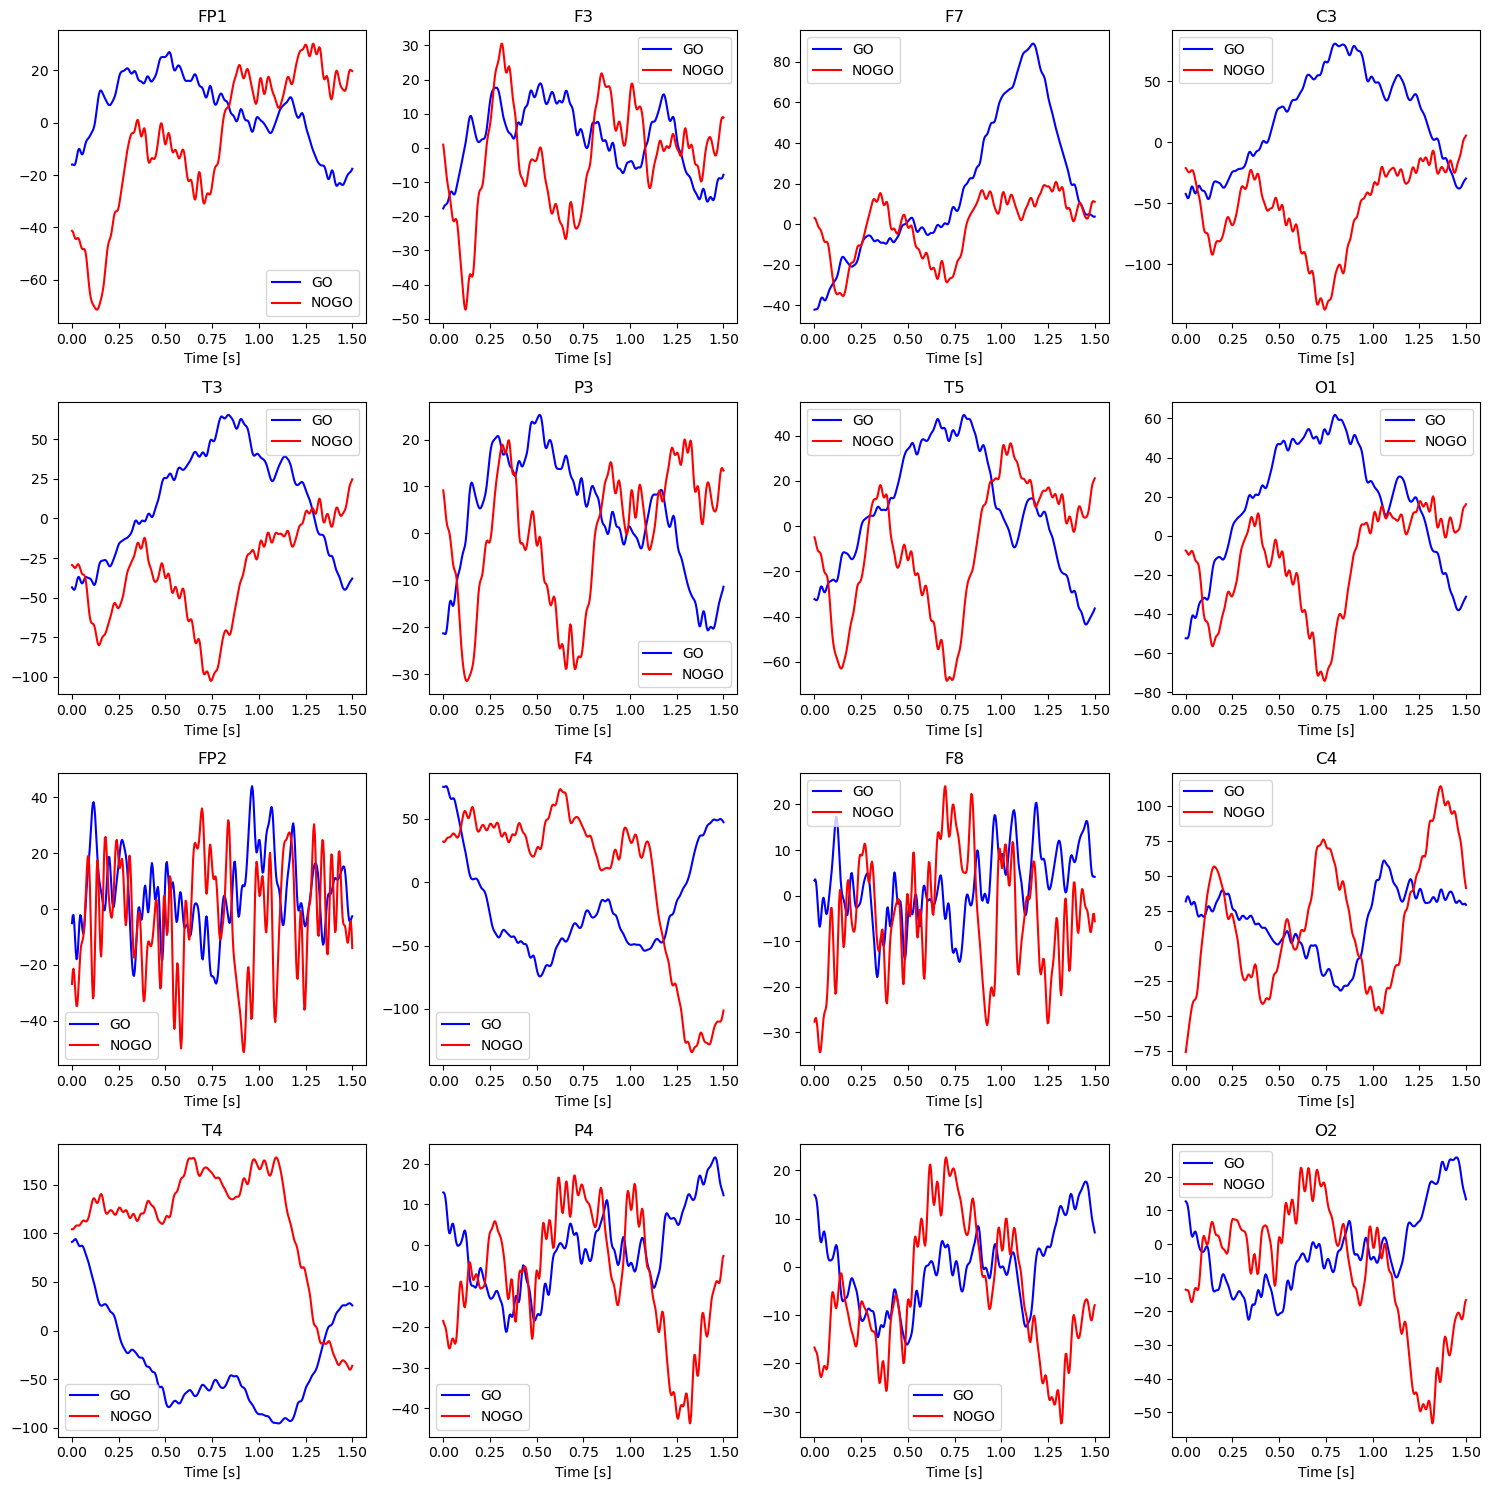

In [27]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot( T_ARRAY, GO_ERP.mean(0)[pos], "b" , label="GO") 
    plt.plot( T_ARRAY, NOGO_ERP.mean(0)[pos], "r"  , label="NOGO") 
    plt.title(CHANNEL_NAMES[pos])
    plt.xlabel("Time [s]")
    plt.legend()
plt.tight_layout()

In [43]:
len(go_onsets)

75

{466008.759979,
 466009.332796,
 466009.332814,
 466012.490934,
 466014.49365,
 466017.504839,
 466018.013391,
 466018.013409,
 466020.781297,
 466022.784712,
 466025.716292,
 466027.717924,
 466030.605899,
 466031.06715,
 466031.06717,
 466034.417524,
 466035.058566,
 466035.058582,
 466038.254861,
 466038.870441,
 466038.870467,
 466041.077004,
 466041.731537,
 466041.731554,
 466045.068441,
 466045.632862,
 466045.632911,
 466049.12629,
 466051.127095,
 466053.653577,
 466054.548538,
 466054.548558,
 466057.286295,
 466059.290257,
 466062.222952,
 466062.722387,
 466062.722415,
 466065.241662,
 466067.244606,
 466070.310731,
 466070.823258,
 466070.823275,
 466073.13109,
 466073.846039,
 466073.846079,
 466076.304006,
 466078.308603,
 466081.795478,
 466082.327757,
 466082.327775,
 466084.951449,
 466086.951783,
 466089.854228,
 466090.277418,
 466090.277441,
 466092.731511,
 466094.736302,
 466097.399448,
 466097.86759,
 466097.86762,
 466100.515331,
 466102.516691,
 466105.156589,